
=== MULTI-REGIME THRESHOLD ANALYSIS (ELITE CAPTURE): OECD (ADVANCED) ===
Executing SSR grid search and locating local minimums...


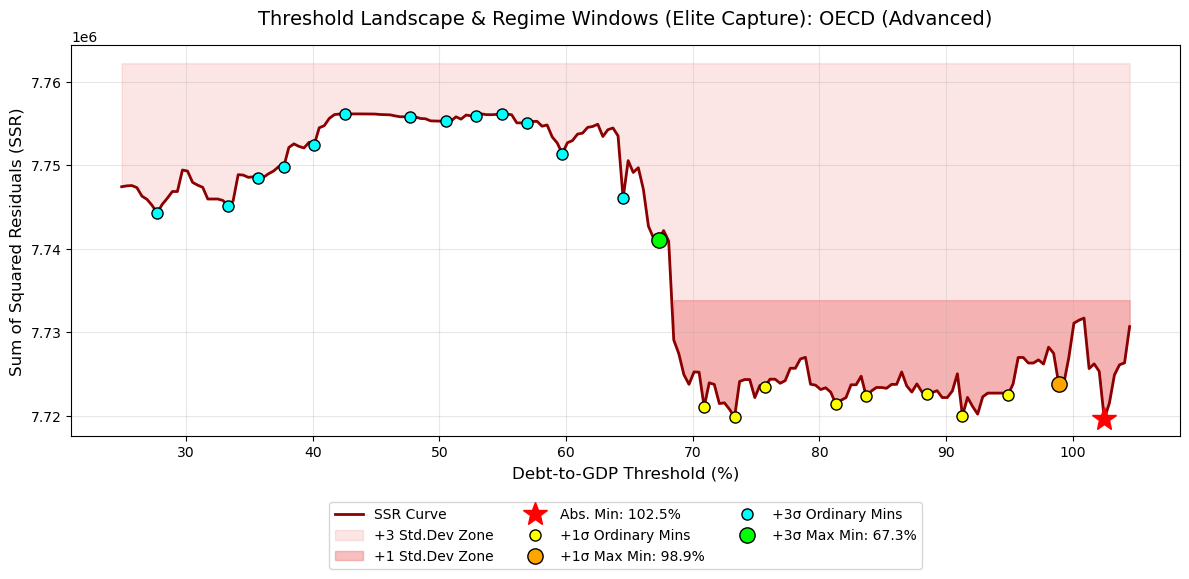

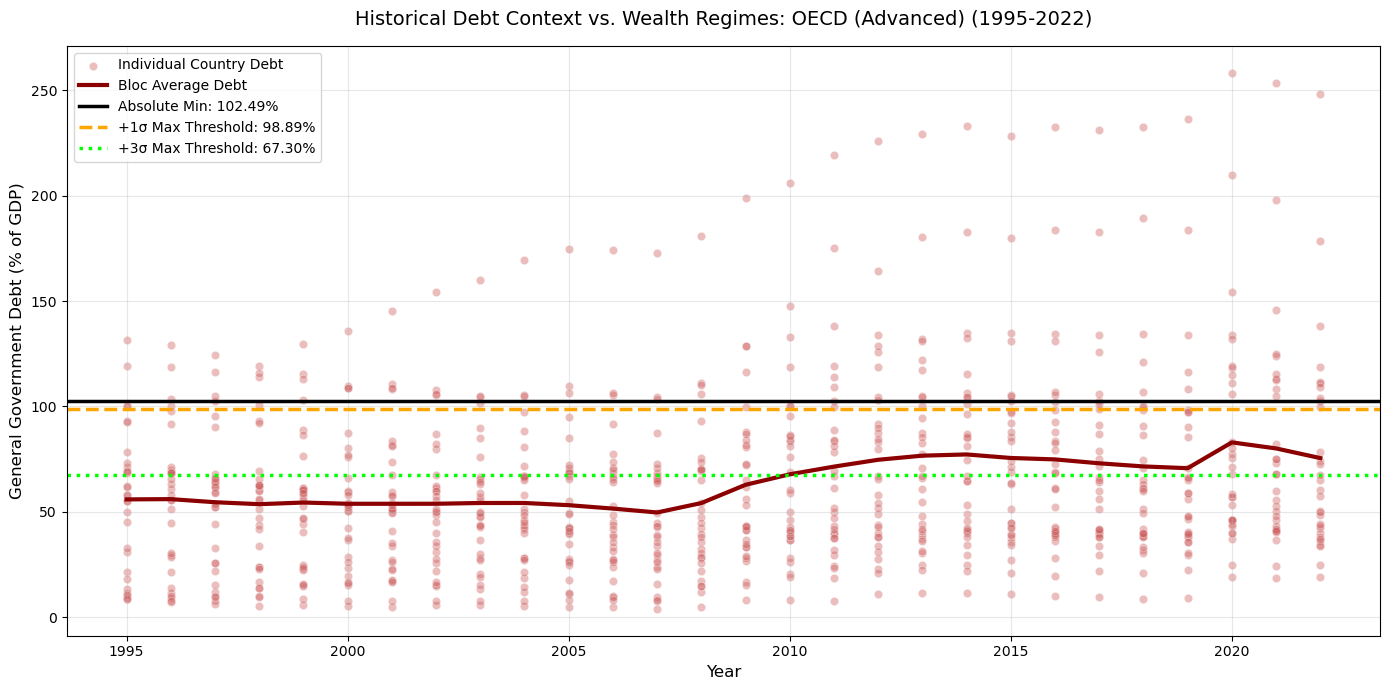


------------------------------------------------------------------------------------------
COUNTRY EXPOSURE ANALYSIS: OECD (Advanced)
------------------------------------------------------------------------------------------

========================= ERA: 1995-2008 (PRE-CRISIS) =========================
                Avg Debt (%)  Avg Elite Ratio  Avg GDP Growth (%) > Abs Min (102.5%) > Max +1σ (98.9%) > Max +3σ (67.3%)
Country Name                                                                                                            
Australia              17.97            11.27                3.71                 NO                NO                NO
Austria                66.88            52.68                2.49                 NO                NO                NO
Belgium               107.74             6.56                2.37                YES               YES               YES
Canada                 81.80             4.02                2.96                 NO    

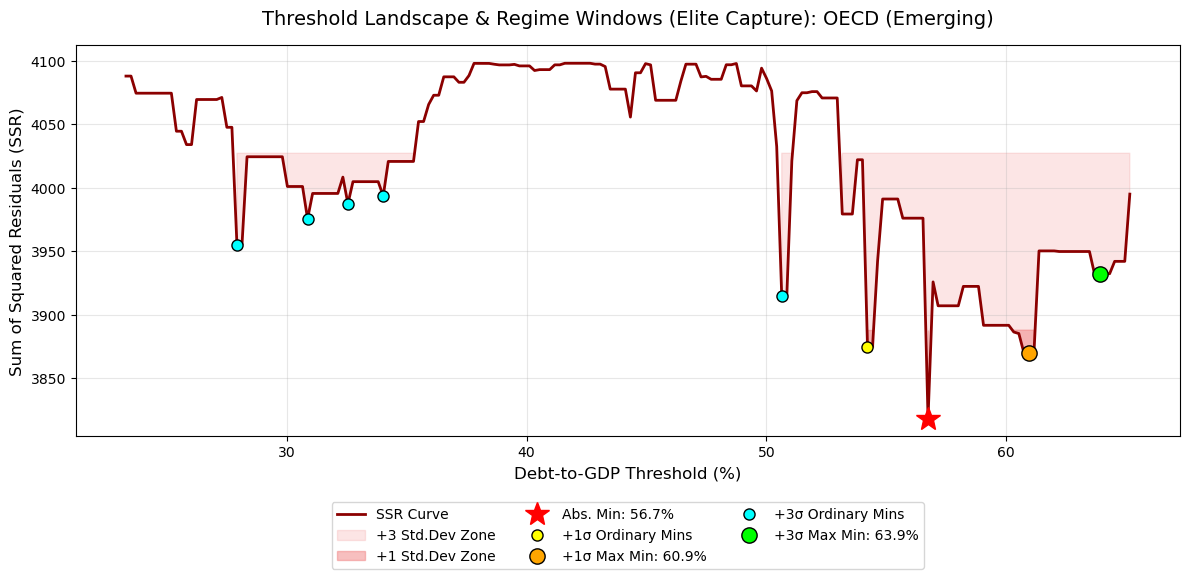

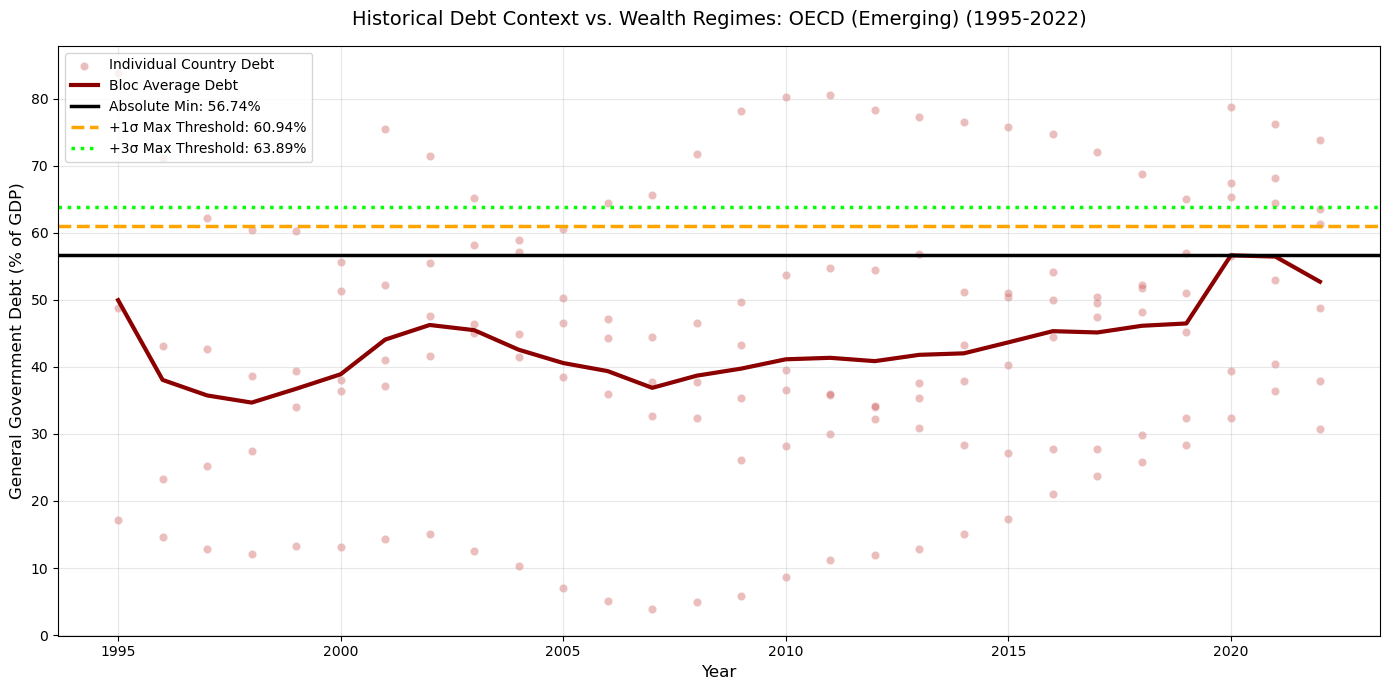


------------------------------------------------------------------------------------------
COUNTRY EXPOSURE ANALYSIS: OECD (Emerging)
------------------------------------------------------------------------------------------

========================= ERA: 1995-2008 (PRE-CRISIS) =========================
              Avg Debt (%)  Avg Elite Ratio  Avg GDP Growth (%) > Abs Min (56.7%) > Max +1σ (60.9%) > Max +3σ (63.9%)
Country Name                                                                                                         
Chile                11.16            38.59                5.09                NO                NO                NO
Colombia             35.58            38.70                3.06                NO                NO                NO
Hungary              62.92            12.55                3.08               YES               YES                NO
Poland               43.12           -59.12                4.77                NO                NO    

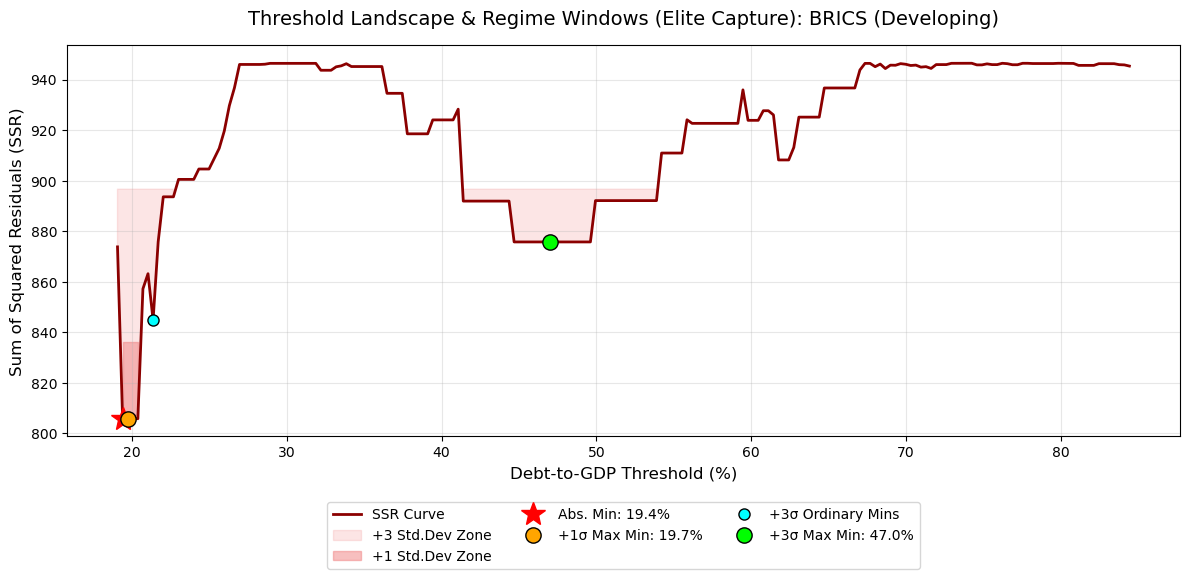

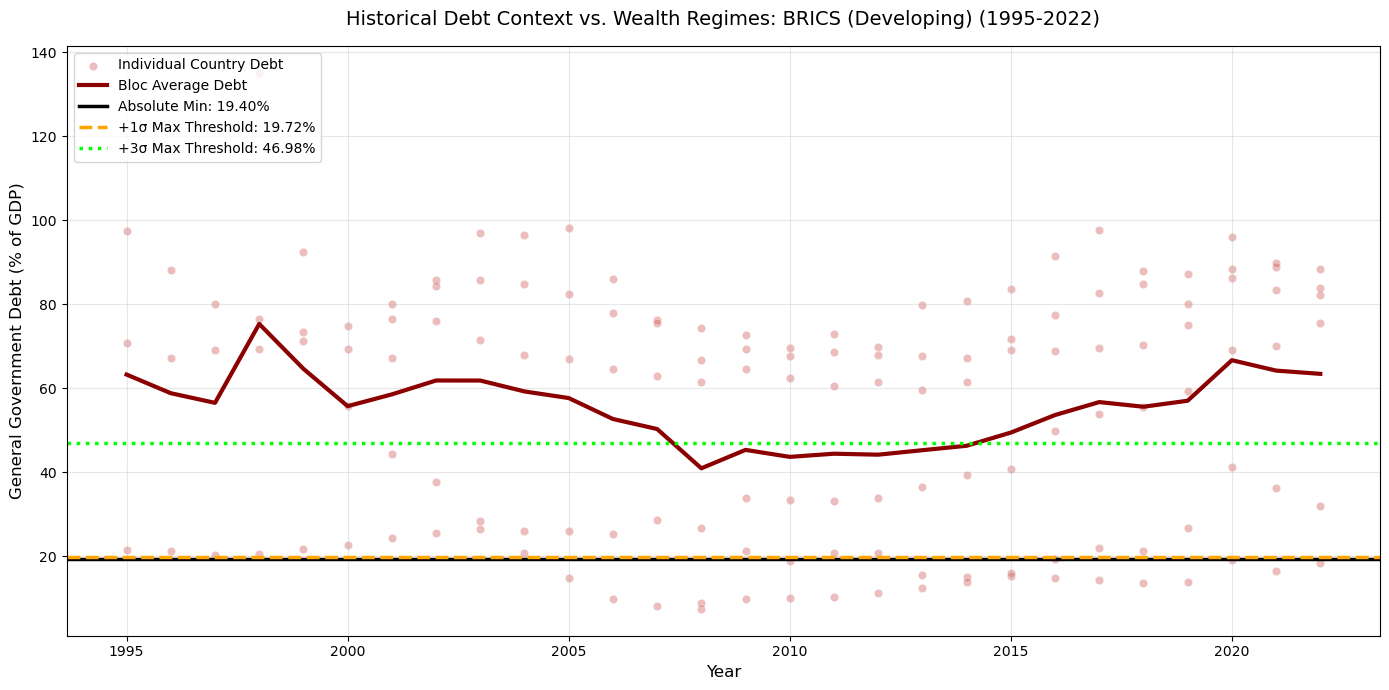


------------------------------------------------------------------------------------------
COUNTRY EXPOSURE ANALYSIS: BRICS (Developing)
------------------------------------------------------------------------------------------

========================= ERA: 1995-2008 (PRE-CRISIS) =========================
                      Avg Debt (%)  Avg Elite Ratio  Avg GDP Growth (%) > Abs Min (19.4%) > Max +1σ (19.7%) > Max +3σ (47.0%)
Country Name                                                                                                                 
Brazil                       67.37            34.95                3.71               YES               YES               YES
China                        24.04             3.64               10.02               YES               YES                NO
Egypt                        83.45            15.49                5.14               YES               YES               YES
India                        76.27             7.85         

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from scipy.signal import find_peaks
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. LOAD MASTER DATA & CALCULATE WEALTH RATIO
# ==============================================================================
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
master_file = PROCESSED_DIR / "master_panel_data.csv"

# Ensure the processed directory exists
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(master_file)
# Sorting the index is crucial for the era-slicing later
df = df.set_index(['Country Name', 'Year']).sort_index()

BRICS_NATIONS = ["Brazil", "Russia", "India", "China", "Egypt", "United Arab Emirates"]
OECD_EMERGING = ["Chile", "Colombia", "Costa Rica", "Turkey", "Hungary", "Poland"]

def categorize_economy(country):
    if country in BRICS_NATIONS: return 'BRICS (Developing)'
    elif country in OECD_EMERGING: return 'OECD (Emerging)'
    else: return 'OECD (Advanced)'

df['Economic_Bloc'] = [categorize_economy(c) for c, y in df.index]

# Calculate the Elite Capture Ratio
TOP_10_COL = 'Wealth Inequality (Top 10%)'
BOTTOM_50_COL = 'Wealth Inequality (Bottom 50%)'
df['Wealth_Ratio_Top10_to_Bottom50'] = df[TOP_10_COL] / df[BOTTOM_50_COL]
df.replace([np.inf, -np.inf], np.nan, inplace=True)

Y_VAR = 'Wealth_Ratio_Top10_to_Bottom50'
DEBT_VAR = 'General Government Debt (% of GDP)'

# Standard WID controls matching 09
EXOG_VARS = [
    'GDP growth (annual %)',
    'Gross capital formation (% of GDP)',
    'Inflation (Annual %)'
]

# ==============================================================================
# 2. LOCAL MINIMUMS & ERA EXPOSURE ALGORITHM (WEALTH REGIMES)
# ==============================================================================
def analyze_threshold_regimes_wealth(data, bloc_name):
    print(f"\n{'='*95}")
    print(f"=== MULTI-REGIME THRESHOLD ANALYSIS (ELITE CAPTURE): {bloc_name.upper()} ===")
    print(f"{'='*95}")
    
    reg_data = data[[Y_VAR, DEBT_VAR] + EXOG_VARS].dropna()
    if len(reg_data) < 30: 
        print("Skipping due to insufficient data.")
        return
        
    min_debt = reg_data[DEBT_VAR].quantile(0.15)
    max_debt = reg_data[DEBT_VAR].quantile(0.85)
    
    # 200 points for smooth signal processing
    grid = np.linspace(min_debt, max_debt, 200)
    ssr_history = []
    
    print("Executing SSR grid search and locating local minimums...")
    for gamma in grid:
        reg_data['Debt_Low'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] <= gamma)
        reg_data['Debt_High'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] > gamma)
        
        Y = reg_data[Y_VAR]
        X = sm.add_constant(reg_data[['Debt_Low', 'Debt_High'] + EXOG_VARS])
        
        # Consistent with 09 and 10
        model = PanelOLS(Y, X, entity_effects=True, time_effects=True)
        res = model.fit(cov_type='robust')
        ssr = float(res.resids.squeeze().dot(res.resids.squeeze()))
        ssr_history.append((gamma, ssr))

    gammas = np.array([x[0] for x in ssr_history])
    ssrs = np.array([x[1] for x in ssr_history])
    
    # --- CALCULATE STATISTICAL BOUNDS ---
    best_ssr = np.min(ssrs)
    best_gamma = gammas[np.argmin(ssrs)]
    ssr_std = np.std(ssrs)
    
    bound_1sd = best_ssr + (1 * ssr_std)
    bound_3sd = best_ssr + (3 * ssr_std)
    
    # --- IDENTIFY AND CLASSIFY LOCAL MINIMUMS ---
    peaks, _ = find_peaks(-ssrs, distance=5) 
    
    # Filter into 1 SD group
    valid_1sd_all = [(gammas[p], ssrs[p]) for p in peaks if ssrs[p] <= bound_1sd and gammas[p] != best_gamma]
    if valid_1sd_all:
        max_1sd = max(valid_1sd_all, key=lambda x: x[0])
        ordinary_1sd = [x for x in valid_1sd_all if x != max_1sd]
    else:
        max_1sd, ordinary_1sd = None, []

    # Filter into 1-to-3 SD group
    valid_3sd_all = [(gammas[p], ssrs[p]) for p in peaks if bound_1sd < ssrs[p] <= bound_3sd and gammas[p] != best_gamma]
    if valid_3sd_all:
        max_3sd = max(valid_3sd_all, key=lambda x: x[0])
        ordinary_3sd = [x for x in valid_3sd_all if x != max_3sd]
    else:
        max_3sd, ordinary_3sd = None, []

    # --- GRAPH 1: SSR LANDSCAPE WITH COLOR-CODED REGIMES ---
    plt.figure(figsize=(12, 6))
    # Using darkred to signify Wealth/Inequality graphs visually throughout your thesis
    plt.plot(gammas, ssrs, color='darkred', linewidth=2, label='SSR Curve')
    
    # Highlight Zones
    plt.fill_between(gammas, ssrs, bound_3sd, where=(ssrs <= bound_3sd), 
                     color='lightcoral', alpha=0.2, label='+3 Std.Dev Zone')
    plt.fill_between(gammas, ssrs, bound_1sd, where=(ssrs <= bound_1sd), 
                     color='lightcoral', alpha=0.5, label='+1 Std.Dev Zone')
    
    # Plot Color-Coded Minimums
    plt.plot(best_gamma, best_ssr, 'r*', markersize=18, label=f'Abs. Min: {best_gamma:.1f}%')
    
    if ordinary_1sd:
        gx, sy = zip(*ordinary_1sd)
        plt.plot(gx, sy, 'o', color='yellow', markersize=8, markeredgecolor='black', label='+1σ Ordinary Mins')
    if max_1sd:
        plt.plot(max_1sd[0], max_1sd[1], 'o', color='orange', markersize=11, markeredgecolor='black', label=f'+1σ Max Min: {max_1sd[0]:.1f}%')
        
    if ordinary_3sd:
        gx, sy = zip(*ordinary_3sd)
        plt.plot(gx, sy, 'o', color='cyan', markersize=8, markeredgecolor='black', label='+3σ Ordinary Mins')
    if max_3sd:
        plt.plot(max_3sd[0], max_3sd[1], 'o', color='lime', markersize=11, markeredgecolor='black', label=f'+3σ Max Min: {max_3sd[0]:.1f}%')

    plt.title(f'Threshold Landscape & Regime Windows (Elite Capture): {bloc_name}', fontsize=14, pad=15)
    plt.xlabel('Debt-to-GDP Threshold (%)', fontsize=12)
    plt.ylabel('Sum of Squared Residuals (SSR)', fontsize=12)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- GRAPH 2: HISTORICAL TIMELINE MAPPING ---
    plt.figure(figsize=(14, 7))
    years = reg_data.index.get_level_values('Year')
    sns.scatterplot(x=years, y=reg_data[DEBT_VAR], alpha=0.4, color='indianred', label='Individual Country Debt')
    
    yearly_avg = reg_data.groupby(level='Year')[DEBT_VAR].mean()
    plt.plot(yearly_avg.index, yearly_avg.values, color='darkred', linewidth=3, label='Bloc Average Debt')

    plt.axhline(y=best_gamma, color='black', linestyle='-', linewidth=2.5, label=f'Absolute Min: {best_gamma:.2f}%')
    if max_1sd:
        plt.axhline(y=max_1sd[0], color='orange', linestyle='--', linewidth=2.5, label=f'+1σ Max Threshold: {max_1sd[0]:.2f}%')
    if max_3sd:
        plt.axhline(y=max_3sd[0], color='lime', linestyle=':', linewidth=2.5, label=f'+3σ Max Threshold: {max_3sd[0]:.2f}%')

    plt.title(f'Historical Debt Context vs. Wealth Regimes: {bloc_name} (1995-2022)', fontsize=14, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('General Government Debt (% of GDP)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- COUNTRY EXPOSURE TABLES WITH WEALTH EXPORT ---
    print("\n" + "-"*90)
    print(f"COUNTRY EXPOSURE ANALYSIS: {bloc_name}")
    print("-" * 90)
    
    def generate_era_table(df_era, era_label):
        if df_era.empty: return
        mean_debt = df_era.groupby(level='Country Name')[DEBT_VAR].mean()
        mean_wealth_ratio = df_era.groupby(level='Country Name')[Y_VAR].mean()
        mean_gdp = df_era.groupby(level='Country Name')['GDP growth (annual %)'].mean()
        
        # Base Table includes Debt, Wealth Ratio, and GDP Growth for comprehensive tracking
        table = pd.DataFrame({
            'Avg Debt (%)': mean_debt.round(2),
            'Avg Elite Ratio': mean_wealth_ratio.round(2),
            'Avg GDP Growth (%)': mean_gdp.round(2)
        })
        
        table[f'> Abs Min ({best_gamma:.1f}%)'] = (mean_debt > best_gamma).map({True: 'YES', False: 'NO'})
        
        if max_1sd:
            table[f'> Max +1σ ({max_1sd[0]:.1f}%)'] = (mean_debt > max_1sd[0]).map({True: 'YES', False: 'NO'})
        if max_3sd:
            table[f'> Max +3σ ({max_3sd[0]:.1f}%)'] = (mean_debt > max_3sd[0]).map({True: 'YES', False: 'NO'})
        
        print(f"\n{'='*25} ERA: {era_label} {'='*25}")
        print(table.to_string())
        
        clean_name = bloc_name.replace(' ', '_').replace('(', '').replace(')', '')
        clean_era = era_label.split()[0].replace('-', '_')
        csv_filename = PROCESSED_DIR / f"Exposure_Wealth_{clean_name}_{clean_era}.csv"
        
        table.to_csv(csv_filename)
        print(f"--> Saved data to: {csv_filename}")
        
    era1_data = reg_data.loc[(slice(None), slice(1995, 2008)), :]
    era2_data = reg_data.loc[(slice(None), slice(2009, 2022)), :]
    
    generate_era_table(era1_data, "1995-2008 (PRE-CRISIS)")
    generate_era_table(era2_data, "2009-2022 (POST-CRISIS)")
    print("="*95 + "\n")

# ==============================================================================
# 3. EXECUTE FOR CORE BLOCS
# ==============================================================================
if __name__ == "__main__":
    for bloc in ['OECD (Advanced)', 'OECD (Emerging)', 'BRICS (Developing)']:
        df_bloc = df[df['Economic_Bloc'] == bloc]
        analyze_threshold_regimes_wealth(df_bloc, bloc)